# DOE Electric Disturbance Events Analysis (2002–2023)
Looking at 22 years of electric grid disturbance data from the DOE OE-417 reports.
Goal is to find trends, see which regions are worst, and pull out some useful insights.

## 0. Imports and Setup

In [2]:
# bring in all the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# set a clean look for all the matplotlib charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
})

BLUE   = '#2563EB'
RED    = '#DC2626'
GREEN  = '#16A34A'

# color map for the event categories
COLORS = {
    'Severe Weather':        '#3B82F6',
    'Intentional / Security':'#DC2626',
    'Operational / Grid':    '#F59E0B',
    'Equipment Failure':     '#8B5CF6',
    'Fuel Supply':           '#10B981',
    'Unknown':               '#9CA3AF',
    'Other':                 '#6B7280',
}

print('libraries loaded')

libraries loaded


## 1. Load the Data

In [3]:
# load the csv
df = pd.read_csv('doe_events_db_ready.csv', parse_dates=['event_start_ts', 'event_end_ts'])

df['year_sheet']  = df['year_sheet'].astype('Int64')
df['event_year']  = df['event_year'].astype('Int64')
df['event_month'] = df['event_month'].astype('Int64')

#print shape and date range
print(f'rows: {df.shape[0]:,}   columns: {df.shape[1]}')
print(f'years covered: {df["year_sheet"].min()} to {df["year_sheet"].max()}')
df.head()

rows: 3,953   columns: 15
years covered: 2002 to 2023


,event_id,year_sheet,event_start_ts,event_end_ts,outage_duration_hours,customers_affected,demand_loss_mw,nerc_region,event_type,alert_criteria,area_affected_raw,event_year,event_month,has_end_ts,has_customers_affected
0,1,2002,2002-01-30 06:00:00,2002-02-07 12:00:00,198.000000,1881134.0,500.0,SPP,Ice Storm,NaN,Oklahoma,2002,1,True,True
1,2,2002,2002-01-29 00:00:00,NaT,NaN,270000.0,550.0,SPP,Ice Storm,NaN,Metropolitan Kansas City Area,2002,1,False,True
2,3,2002,2002-01-30 16:00:00,2002-02-10 21:00:00,269.000000,95000.0,210.0,SPP,Ice Storm,NaN,Missouri,2002,1,True,True
3,4,2002,2002-02-27 10:48:00,2002-02-27 11:35:00,0.783333,255000.0,300.0,WSCC,Interruption of Firm Load,NaN,California,2002,2,True,True
4,5,2002,2002-03-09 00:00:00,2002-03-11 12:00:00,60.000000,190000.0,190.0,ECAR,Severe Weather,NaN,Lower Peninsula of Michigan,2002,3,True,True


## 2. How Many Events Per Year - Overall Trend

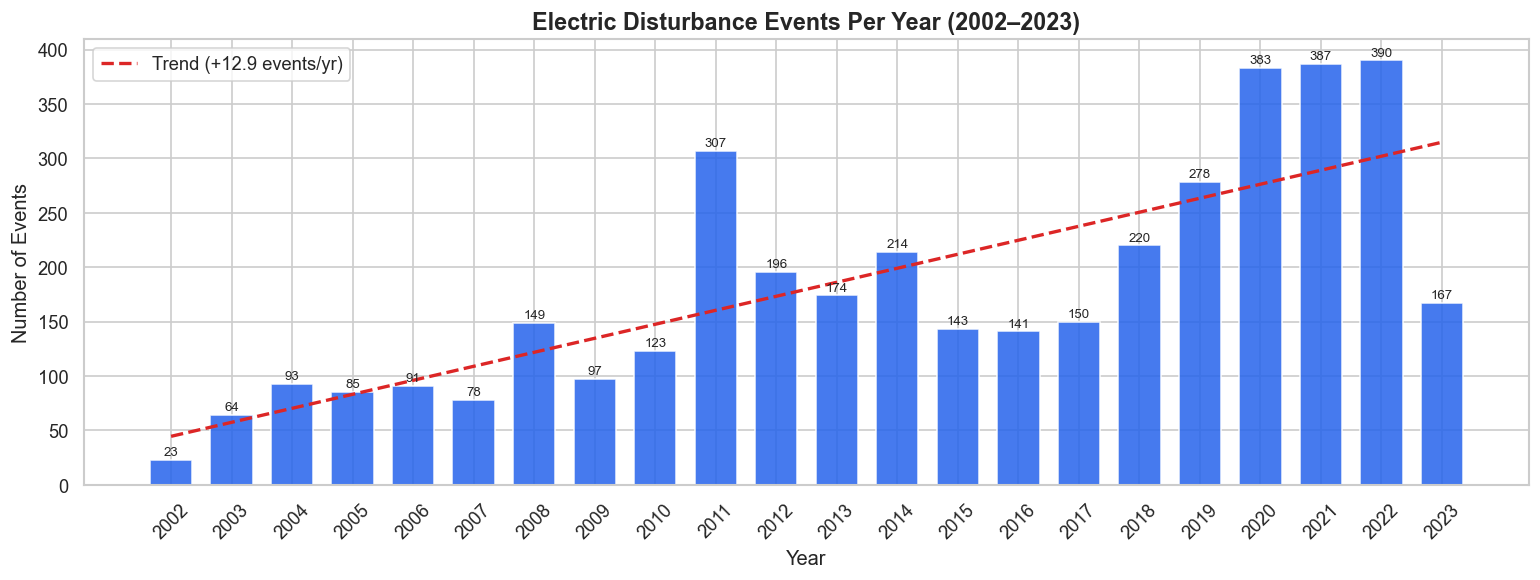

In [4]:
# count events per year
annual = df.groupby('year_sheet').size().reset_index(name='events')


fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(annual['year_sheet'], annual['events'], color=BLUE, alpha=0.85, width=0.7)

# simple linear trend line
z = np.polyfit(annual['year_sheet'].astype(int), annual['events'], 1)
p = np.poly1d(z)
ax.plot(annual['year_sheet'], p(annual['year_sheet'].astype(int)),
        '--', color=RED, linewidth=2, label=f'Trend (+{z[0]:.1f} events/yr)')

for _, row in annual.iterrows():
    ax.text(row['year_sheet'], row['events'] + 1.5, str(row['events']),
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Year')
ax.set_ylabel('Number of Events')
ax.set_title('Electric Disturbance Events Per Year (2002–2023)')
ax.legend(fontsize=11)
ax.set_xticks(annual['year_sheet'])
ax.set_xticklabels(annual['year_sheet'], rotation=45)
plt.tight_layout()
plt.show()


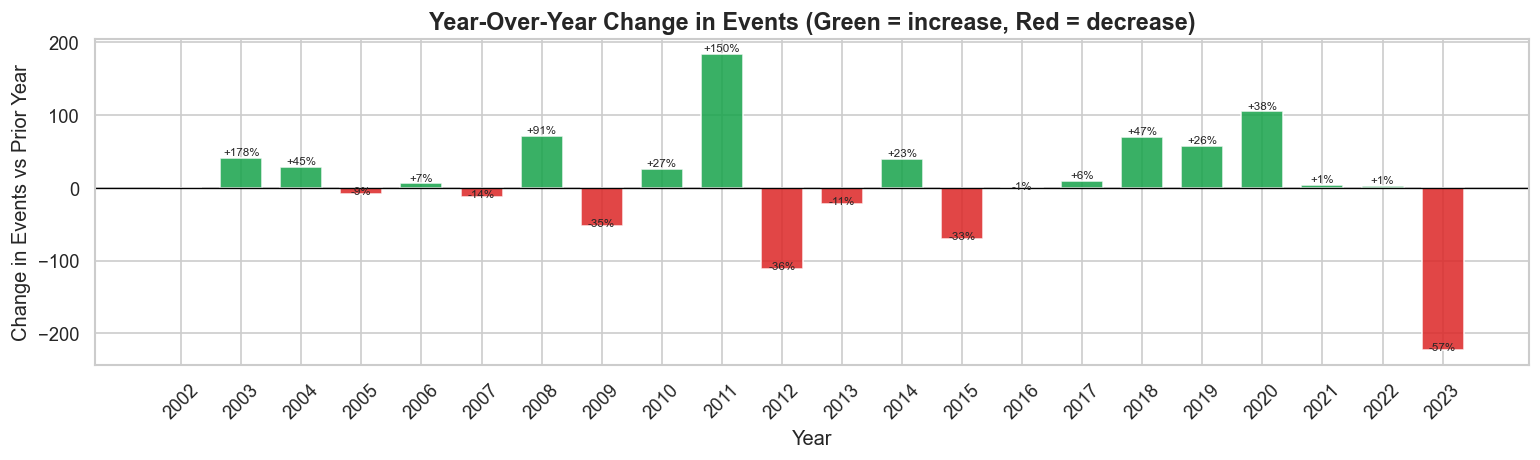

In [5]:
# year over year growth rate
annual['yoy_change']  = annual['events'].diff()
annual['yoy_pct']     = annual['events'].pct_change() * 100

fig, ax = plt.subplots(figsize=(13, 4))
colors = [GREEN if v >= 0 else RED for v in annual['yoy_change'].fillna(0)]
ax.bar(annual['year_sheet'], annual['yoy_change'].fillna(0), color=colors, alpha=0.85, width=0.7)
ax.axhline(0, color='black', linewidth=0.8)

# label each bar with the percent change
for _, row in annual.iterrows():
    if pd.notna(row['yoy_pct']):
        ax.text(row['year_sheet'], row['yoy_change'] + (1 if row['yoy_change'] >= 0 else -3),
                f"{row['yoy_pct']:+.0f}%", ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Year')
ax.set_ylabel('Change in Events vs Prior Year')
ax.set_title('Year-Over-Year Change in Events (Green = increase, Red = decrease)')
ax.set_xticks(annual['year_sheet'])
ax.set_xticklabels(annual['year_sheet'], rotation=45)
plt.tight_layout()
plt.show()

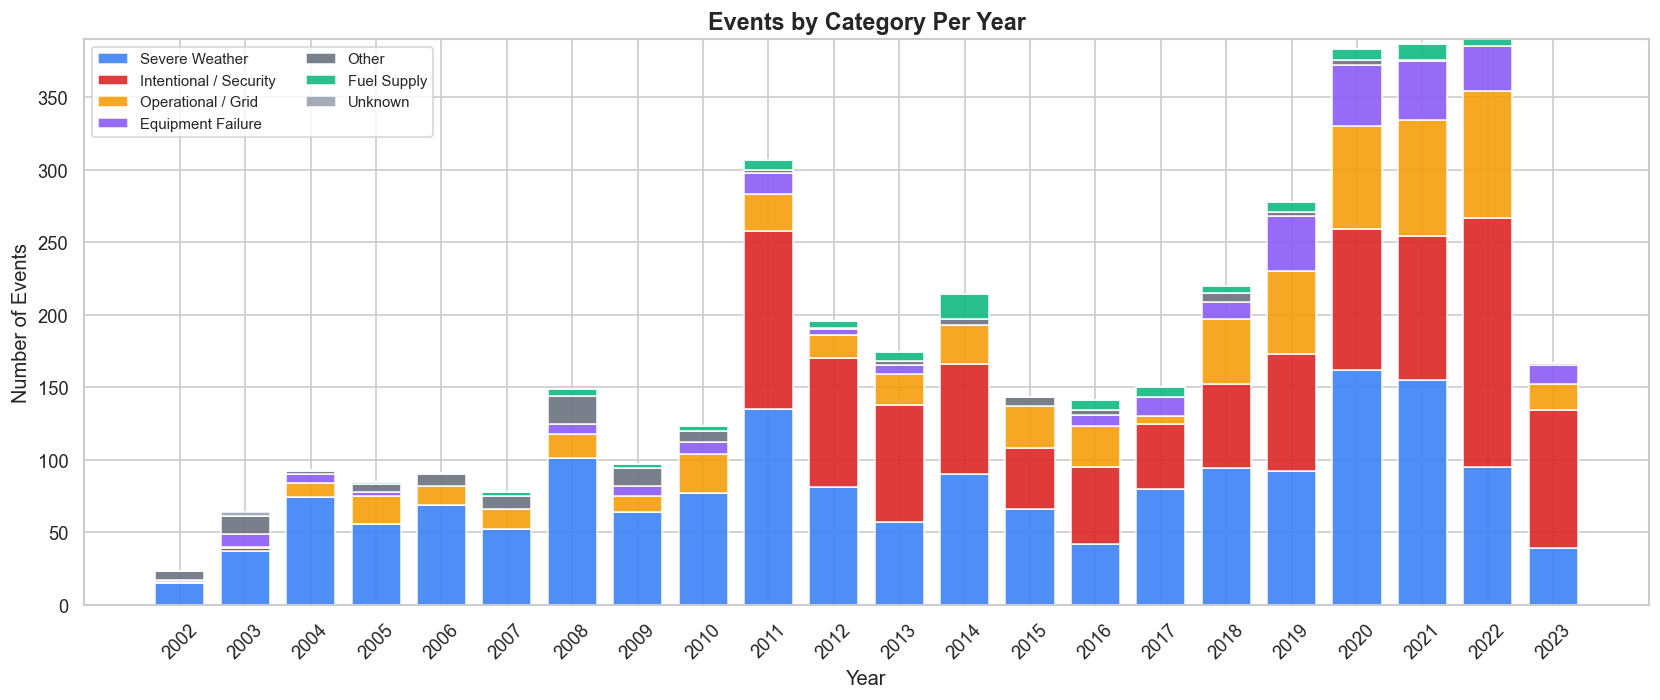

In [6]:

def classify_event(t):
    if pd.isna(t):
        return 'Unknown'
    t = str(t).lower()
    # check for intentional events first
    if any(k in t for k in ['vandal', 'attack', 'sabotage', 'cyber', 'suspicious', 'physical']):
        return 'Intentional / Security'
    # weather events
    if any(k in t for k in ['hurricane', 'storm', 'wind', 'ice', 'snow', 'flood',
                              'tornado', 'weather', 'rain', 'wildfire', 'fire',
                              'lightning', 'heat']):
        return 'Severe Weather'
    # fuel supply
    if any(k in t for k in ['fuel supply', 'fuel deficiency', 'coal', 'natural gas', 'hydro']):
        return 'Fuel Supply'
    
    if any(k in t for k in ['equipment', 'transmission', 'generation', 'fault',
                              'breaker', 'transformer', 'relay', 'cable']):
        return 'Equipment Failure'
    if any(k in t for k in ['public appeal', 'voltage reduction', 'load shed',
                              'islanding', 'system operations', 'inadequate']):
        return 'Operational / Grid'
    return 'Other'

df['category'] = df['event_type'].apply(classify_event)

cat_year = df.groupby(['year_sheet', 'category']).size().unstack(fill_value=0)

# put categories in order of most to least common
cat_order = df['category'].value_counts().index.tolist()
cat_year = cat_year[[c for c in cat_order if c in cat_year.columns]]

# stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(cat_year))
for col in cat_year.columns:
    color = COLORS.get(col, '#6B7280')
    ax.bar(cat_year.index, cat_year[col], bottom=bottom,
           label=col, color=color, alpha=0.9, width=0.75)
    bottom += cat_year[col].values

ax.set_xlabel('Year')
ax.set_ylabel('Number of Events')
ax.set_title('Events by Category Per Year')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.set_xticks(cat_year.index)
ax.set_xticklabels(cat_year.index, rotation=45)
plt.tight_layout()
plt.show()

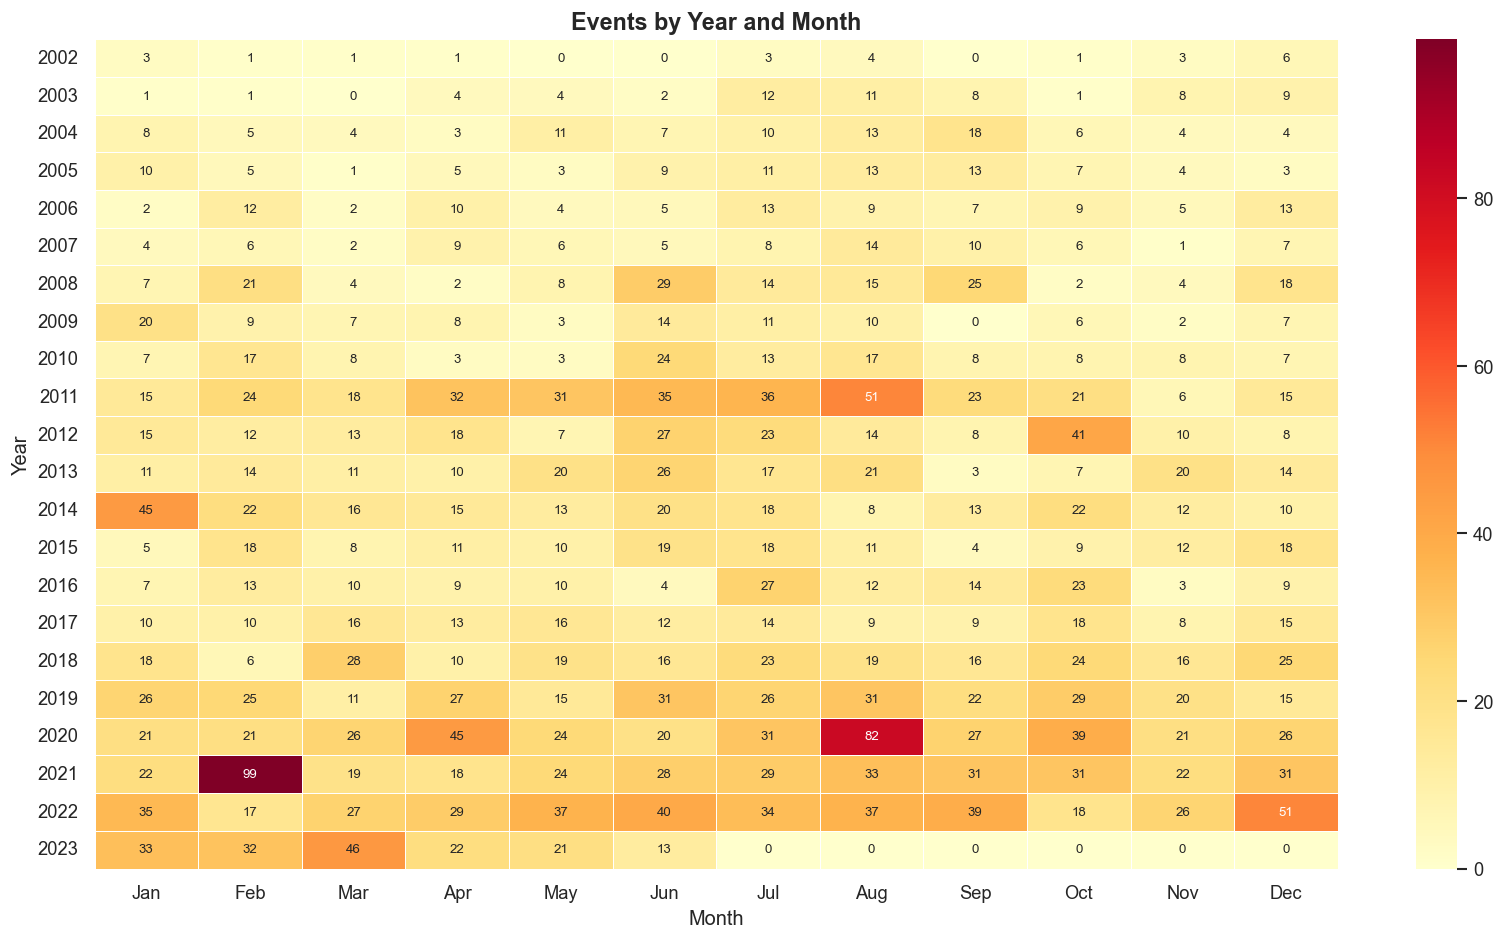

In [7]:
# make a heatmap showing how many events happened each month of each year
pivot = df.groupby(['year_sheet', 'event_month']).size().unstack(fill_value=0)

# rename columns from numbers to month names
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot.columns = month_names[:len(pivot.columns)]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, linecolor='white',
            annot=True, fmt='d', annot_kws={'size': 8}, ax=ax)
ax.set_title('Events by Year and Month')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()


## 3. How Bad Were the Events - Severity and Impact

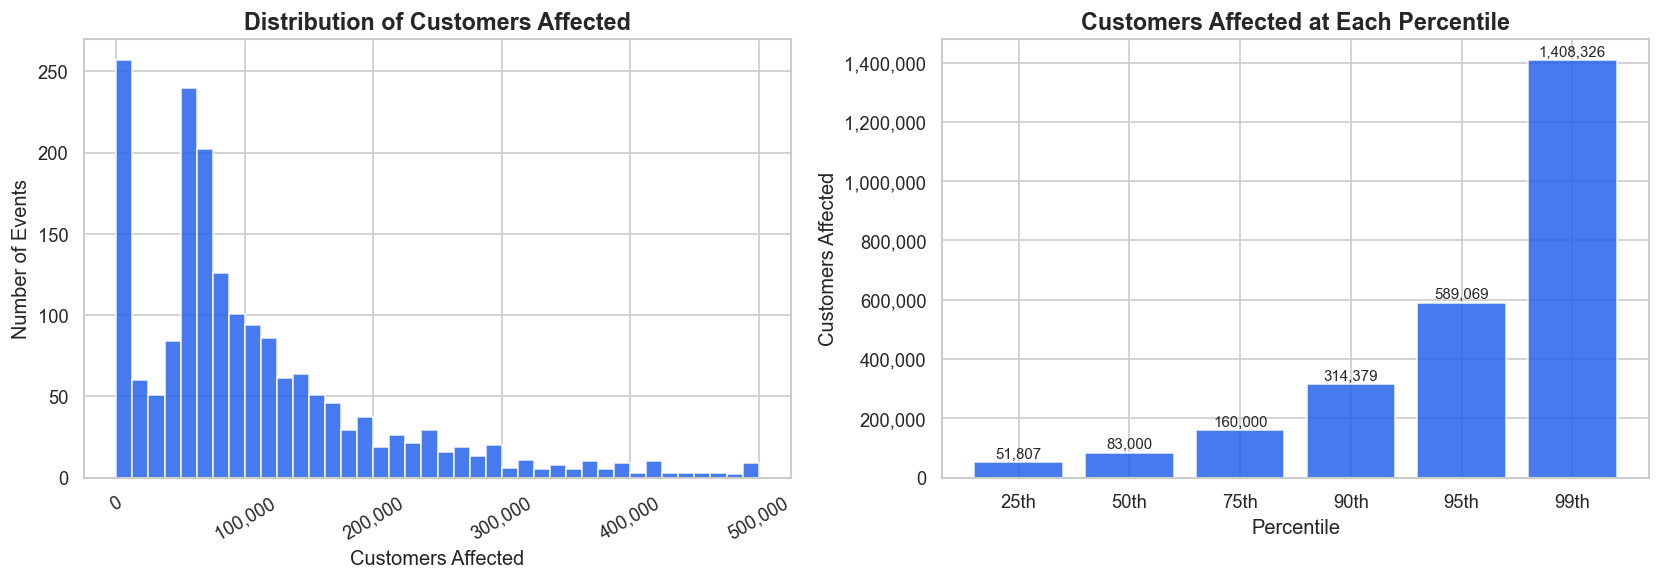

median:      83,000customers
mean:      165,575customers
max:    4,645,572customers
events affecting 1M+ : 43


In [8]:
# drop nulls and zeros
cust = df['customers_affected'].dropna()
cust = cust[cust > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left plot histogram
cutoff = 500_000
cust_trimmed = cust[cust <= cutoff]
axes[0].hist(cust_trimmed, bins=40, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_xlabel('Customers Affected')
axes[0].set_ylabel('Number of Events')
axes[0].set_title(f'Distribution of Customers Affected')
axes[0].tick_params(axis='x', rotation=30)

# right plot simple bar chart 
percentiles = [25, 50, 75, 90, 95, 99]
values = [cust.quantile(p/100) for p in percentiles]
bars = axes[1].bar([f'{p}th' for p in percentiles], values, color=BLUE, alpha=0.85)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('Percentile')
axes[1].set_ylabel('Customers Affected')
axes[1].set_title('Customers Affected at Each Percentile')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

# print the key stats
print(f'median:{cust.median():>12,.0f}customers')
print(f'mean: {cust.mean():>12,.0f}customers')
print(f'max: {cust.max():>12,.0f}customers')
print(f'events affecting 1M+ : {(cust >= 1_000_000).sum()}')

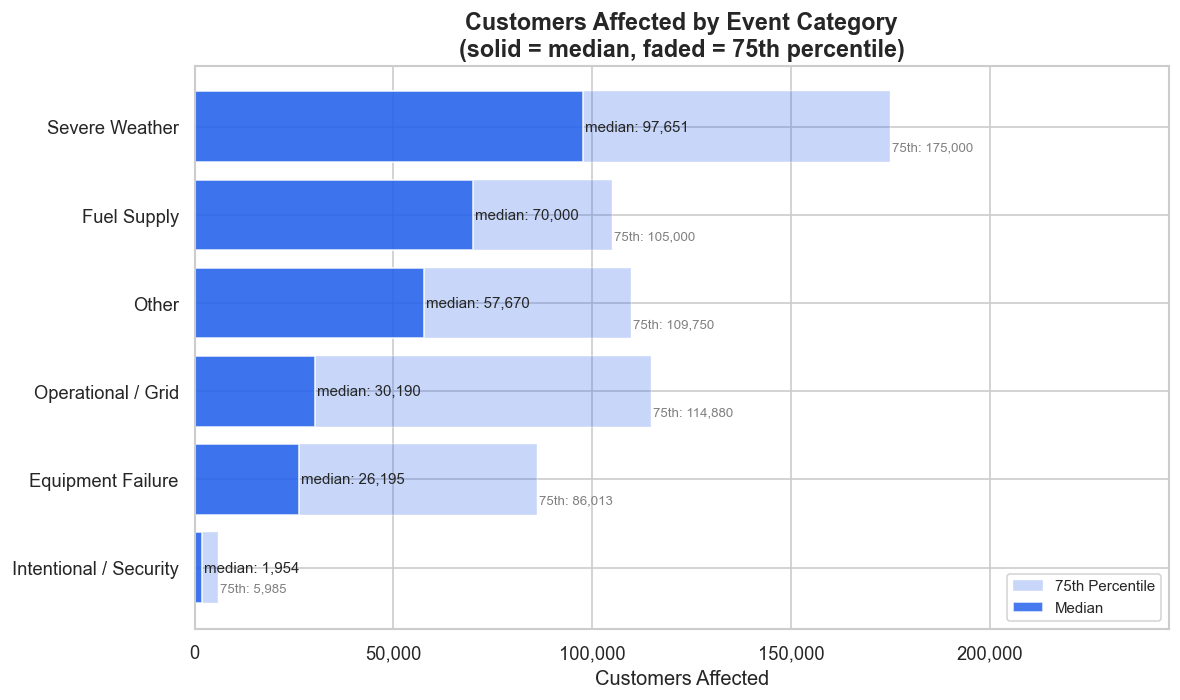

In [9]:
cust_cat = df[df['customers_affected'].notna() & (df['customers_affected'] > 0)].copy()
cust_cat = cust_cat[cust_cat['category'] != 'Unknown']

cust_stats = (
    cust_cat.groupby('category')['customers_affected']
    .agg(median='median', p75=lambda x: x.quantile(0.75))
    .sort_values('median', ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

# draw 75th percentile bar first
ax.barh(cust_stats['category'], cust_stats['p75'], color=BLUE, alpha=0.25, label='75th Percentile')
# draw median bar on top
ax.barh(cust_stats['category'], cust_stats['median'], color=BLUE, alpha=0.85, label='Median')

# label both values
for i, row in cust_stats.iterrows():
    ax.text(row['median'] + 500, i, f"median: {row['median']:,.0f}", va='center', fontsize=9)
    ax.text(row['p75'] + 500, i - 0.25, f"75th: {row['p75']:,.0f}", va='center', fontsize=8, color='gray')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlabel('Customers Affected')
ax.set_title('Customers Affected by Event Category\n(solid = median, faded = 75th percentile)')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, cust_stats['p75'].max() * 1.4)
plt.tight_layout()
plt.show()

In [10]:
# pull out the 15 worst events by customers affected and display them as a table
top_cust = (
    df[df['customers_affected'].notna()]
    .nlargest(15, 'customers_affected')
    [['year_sheet', 'event_start_ts', 'event_type', 'nerc_region',
      'area_affected_raw', 'customers_affected', 'demand_loss_mw',
      'outage_duration_hours']]
    .reset_index(drop=True)
)
top_cust.index += 1

top_cust['area_affected_raw'] = top_cust['area_affected_raw'].str[:30]

# format numbers so they are readable
top_cust['customers_affected']    = top_cust['customers_affected'].apply(lambda x: f'{x:,.0f}')
top_cust['demand_loss_mw']        = top_cust['demand_loss_mw'].apply(
    lambda x: f'{x:,.0f}' if pd.notna(x) else 'N/A')
top_cust['outage_duration_hours'] = top_cust['outage_duration_hours'].apply(
    lambda x: f'{x:.1f} hrs' if pd.notna(x) else 'N/A')

print('TOP 15 EVENTS BY CUSTOMERS AFFECTED')
print('='*80)
display(top_cust)

TOP 15 EVENTS BY CUSTOMERS AFFECTED


,year_sheet,event_start_ts,event_type,nerc_region,area_affected_raw,customers_affected,demand_loss_mw,outage_duration_hours
1,2012,2012-06-29 17:15:00,Severe Weather - Thunderstorms,RFC,Eastern Indiana; Northern Kent,"4,645,572","2,946",78.7 hrs
2,2018,2018-06-22 14:38:00,Severe Weather,WECC,Washington:,"4,200,000","10,000",N/A
3,2014,2014-04-27 09:15:00,Electrical System Separation (Islanding),WECC,"Alberta, Canada","4,000,000","9,750",N/A
4,2017,2017-09-09 12:30:00,Severe Weather,FRCC,Florida:,"3,500,000",N/A,N/A
5,2005,2005-10-23 20:00:00,Hurricane Wilma,FRCC,"South Florida, Naples, Ft. Mye","3,241,437","10,000",18.0 hrs
6,2003,2003-08-14 16:11:00,Unknown *,NPCC,Entire Con Edison System (five,"3,125,350","11,202",28.9 hrs
7,2004,2004-09-04 08:00:00,Hurricane Frances,FRCC,West Palm Beach to Daytona Bea,"2,775,093","6,000",48.0 hrs
8,2008,2008-01-04 04:00:00,Winter Storm,WECC,Northern California,"2,606,931",500,253.0 hrs
9,2008,2008-09-12 18:21:00,Hurricane Ike,TRE,Greater Houston Area-Eastern R,"2,504,366",N/A,461.6 hrs
10,2008,2008-09-12 18:21:00,Hurricane Ike,TRE,Greater Houston-Galveston Metr,"2,142,678","8,087",461.6 hrs


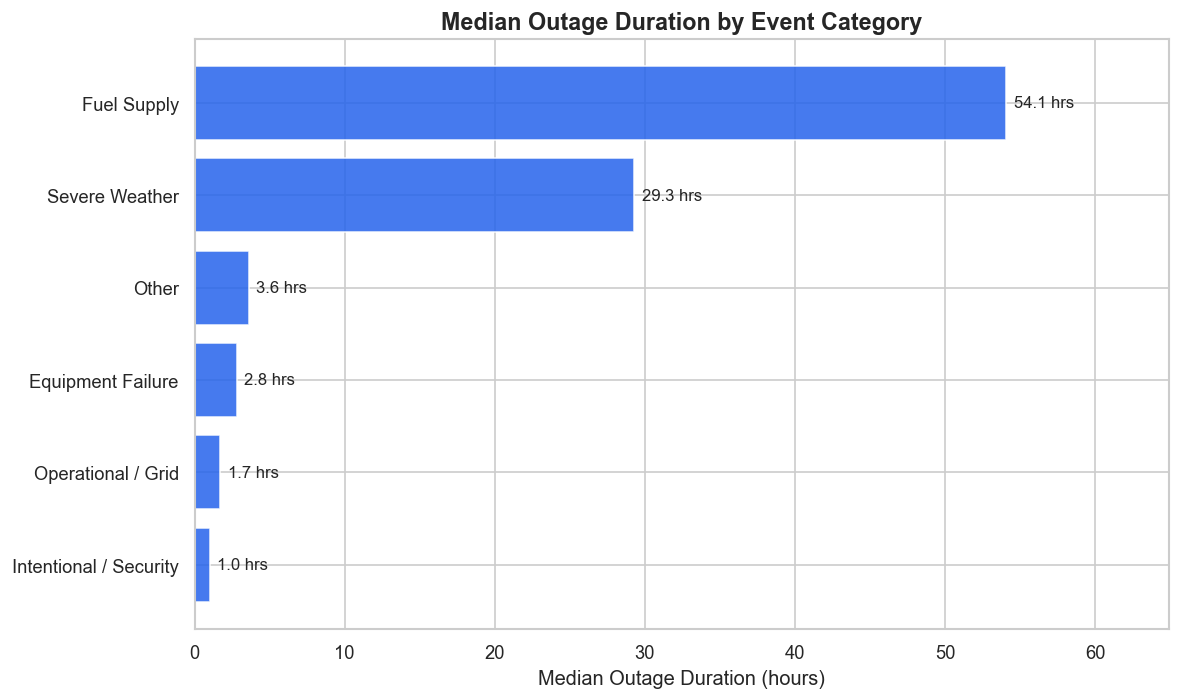

In [11]:
# bar chart showing median outage duration per category
dur = df[
    df['has_end_ts'] &
    df['outage_duration_hours'].notna() &
    (df['outage_duration_hours'] > 0) &
    (df['outage_duration_hours'] < 1000)
].copy()

# calculate median duration for each category
median_dur = (
    dur.groupby('category')['outage_duration_hours']
    .median()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(median_dur.index, median_dur.values, color=BLUE, alpha=0.85)

# add the actual number on each bar
for bar, val in zip(bars, median_dur.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} hrs', va='center', fontsize=10)

ax.set_xlabel('Median Outage Duration (hours)')
ax.set_title('Median Outage Duration by Event Category')
ax.set_xlim(0, median_dur.max() * 1.2)
plt.tight_layout()
plt.show()


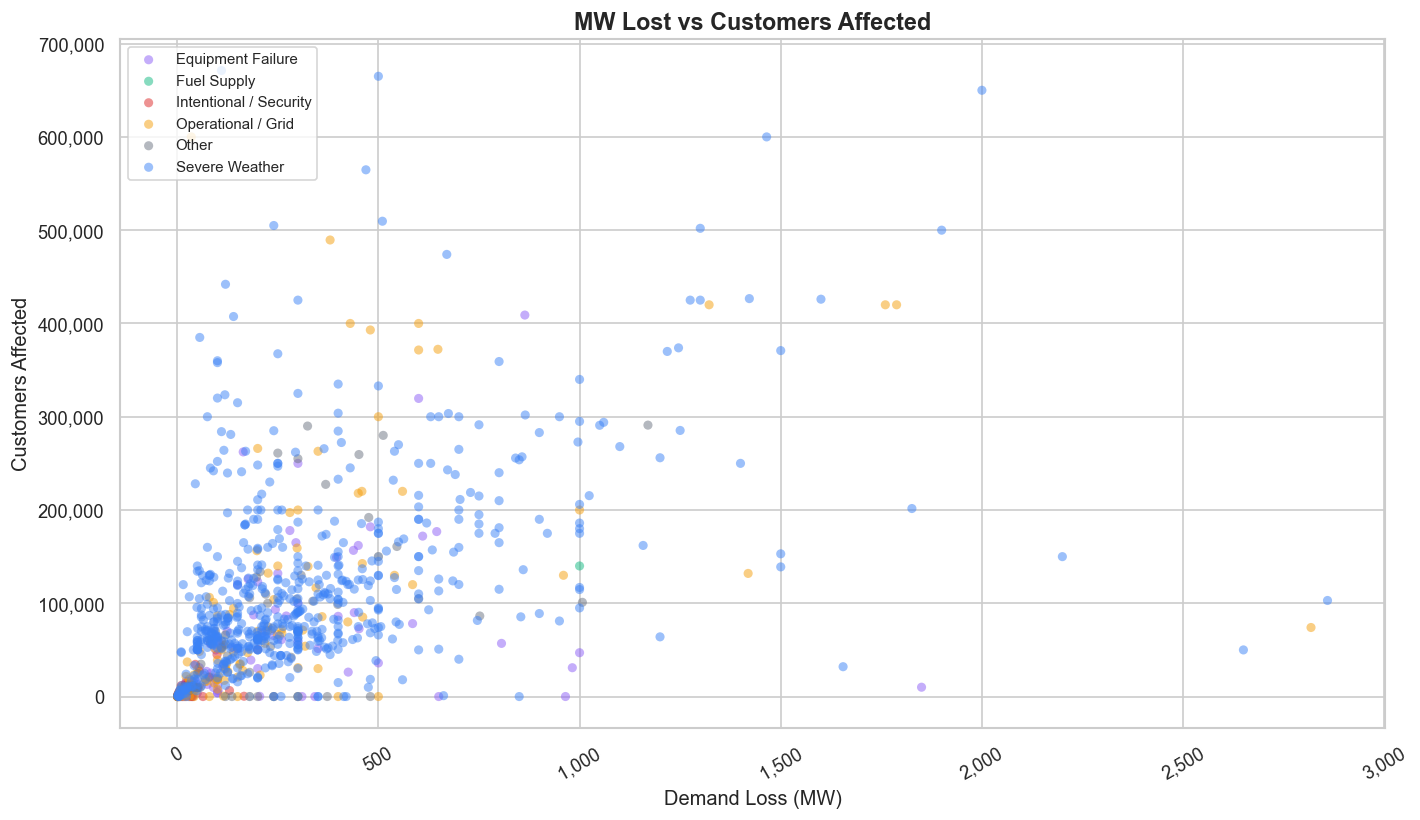

In [12]:
# scatter plot: MW lost vs customers affected
mw_data_scatter = df[
    df['demand_loss_mw'].notna() &
    df['customers_affected'].notna() &
    (df['demand_loss_mw'] > 0) &
    (df['customers_affected'] > 0)
].copy()

mw_cap   = mw_data_scatter['demand_loss_mw'].quantile(0.95)
cust_cap = mw_data_scatter['customers_affected'].quantile(0.95)
mw_data_scatter = mw_data_scatter[
    (mw_data_scatter['demand_loss_mw'] <= mw_cap) &
    (mw_data_scatter['customers_affected'] <= cust_cap)
]

fig, ax = plt.subplots(figsize=(12, 7))

# plot each category separately
for cat, group in mw_data_scatter.groupby('category'):
    ax.scatter(
        group['demand_loss_mw'],
        group['customers_affected'],
        label=cat,
        color=COLORS.get(cat, '#6B7280'),
        alpha=0.5,
        s=30,
        edgecolors='none'
    )

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlabel('Demand Loss (MW)')
ax.set_ylabel('Customers Affected')
ax.set_title('MW Lost vs Customers Affected')
ax.legend(loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 4. Regional Breakdown

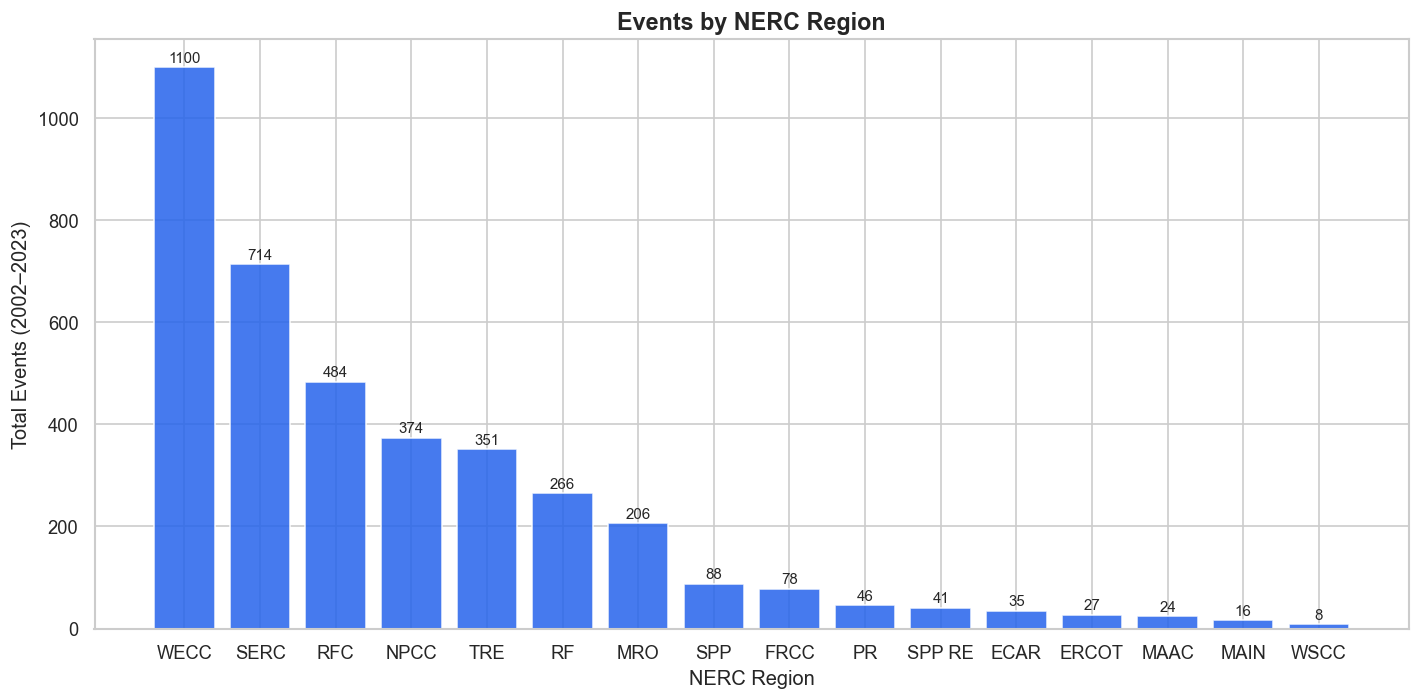

In [13]:
# only keep rows where nerc_region is a single region 
region_df = df[~df['nerc_region'].astype(str).str.contains('/', na=True)].copy()

# count events per region
region_counts = region_df['nerc_region'].value_counts().head(16)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(region_counts.index, region_counts.values,
              color=BLUE, alpha=0.85, edgecolor='white')

# label each bar with the count
for bar, val in zip(bars, region_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            str(val), ha='center', va='bottom', fontsize=9)

ax.set_xlabel('NERC Region')
ax.set_ylabel('Total Events (2002–2023)')
ax.set_title('Events by NERC Region')
plt.tight_layout()
plt.show()

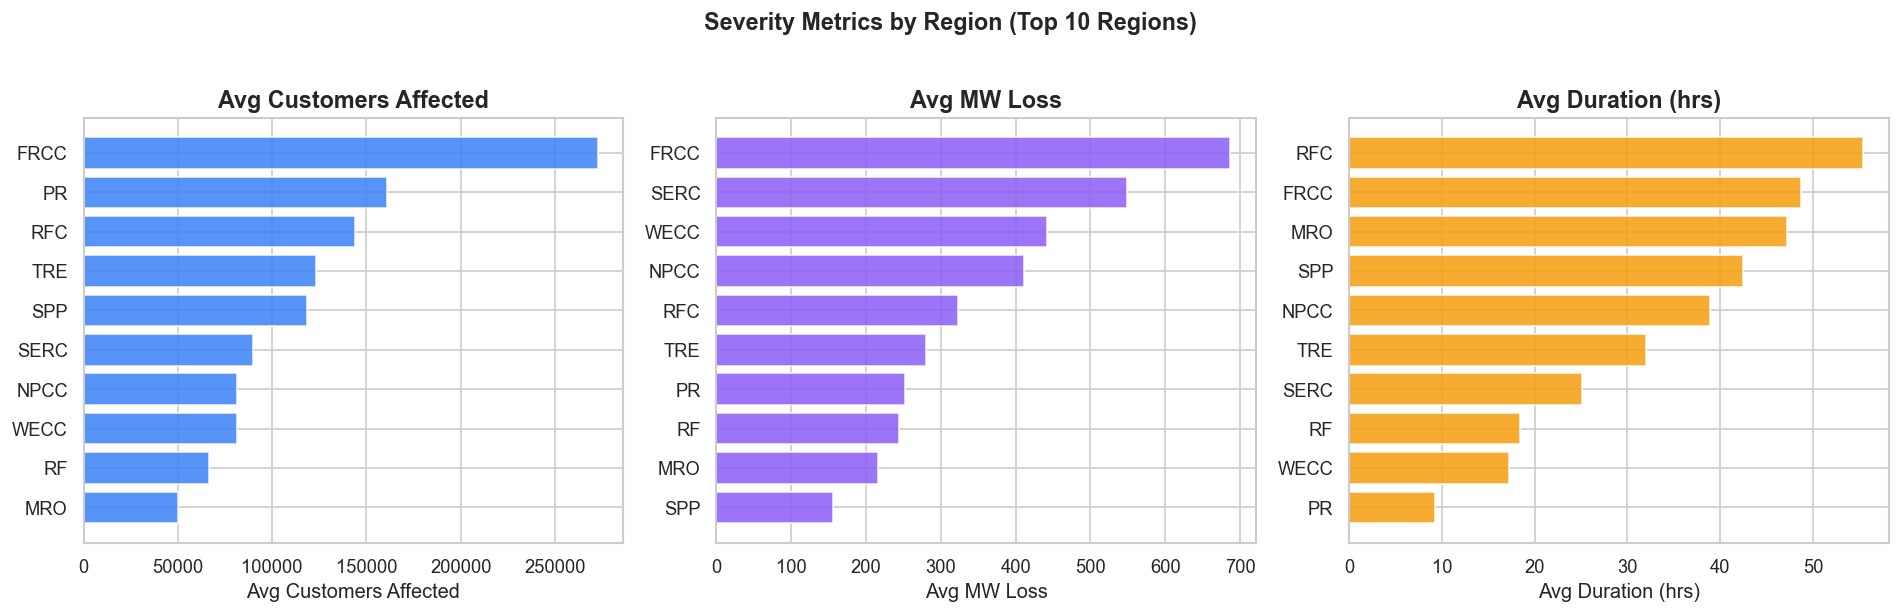

In [14]:
# for the top 10 regions calculate average customers affected, MW loss, and outage duration
top_regions = region_counts.head(10).index.tolist()

region_stats = (
    region_df[region_df['nerc_region'].isin(top_regions)]
    .groupby('nerc_region')
    .agg(
        total_events     = ('event_id', 'count'),
        avg_customers    = ('customers_affected', 'mean'),
        median_customers = ('customers_affected', 'median'),
        avg_mw_loss      = ('demand_loss_mw', 'mean'),
        avg_duration_hrs = ('outage_duration_hours', 'mean'),
    )
    .round(1)
    .sort_values('total_events', ascending=False)
    .reset_index()
)

# three side by side bar charts for the three severity metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('avg_customers',    'Avg Customers Affected', '#3B82F6'),
    ('avg_mw_loss',      'Avg MW Loss',            '#8B5CF6'),
    ('avg_duration_hrs', 'Avg Duration (hrs)',     '#F59E0B'),
]

for ax, (col, title, color) in zip(axes, metrics):
    # drop rows where the metric is null
    sorted_df = region_stats.dropna(subset=[col]).sort_values(col, ascending=True)
    ax.barh(sorted_df['nerc_region'], sorted_df[col], color=color, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(title)

plt.suptitle('Severity Metrics by Region (Top 10 Regions)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# interactive line chart
rpy = (
    region_df[region_df['nerc_region'].isin(top_regions)]
    .groupby(['year_sheet', 'nerc_region'])
    .size()
    .reset_index(name='events')
)

fig = px.line(
    rpy,
    x='year_sheet',
    y='events',
    color='nerc_region',
    markers=True,
    title='Annual Events by NERC Region (Top 10)',
    labels={'year_sheet': 'Year', 'events': 'Events', 'nerc_region': 'Region'},
    template='plotly_white'
)
fig.update_layout(height=480, legend_title='NERC Region')
fig.show()

## 5. Security and Intentional Attacks

Incidents did were not required to be reported before 2011

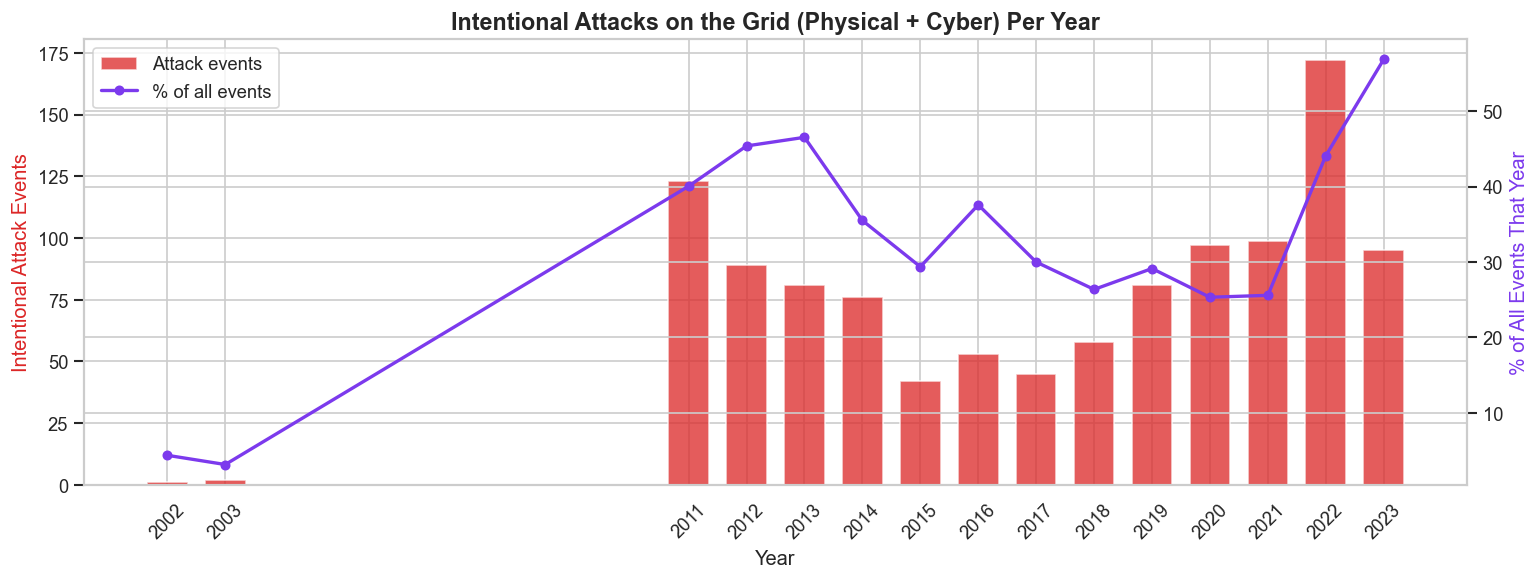

total intentional attack events in dataset: 1,114
peak year: 2022 (172 events)


In [16]:
# filter down to just the intentional / security events
security = df[df['category'] == 'Intentional / Security'].copy()

# count attacks per year and calculate %
sec_year  = security.groupby('year_sheet').size().reset_index(name='attacks')
total_yr  = df.groupby('year_sheet').size().reset_index(name='total')
sec_pct   = sec_year.merge(total_yr, on='year_sheet')
sec_pct['pct'] = sec_pct['attacks'] / sec_pct['total'] * 100

# dual axis chart
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(sec_pct['year_sheet'], sec_pct['attacks'],
        color=RED, alpha=0.75, width=0.7, label='Attack events')
ax2.plot(sec_pct['year_sheet'], sec_pct['pct'],
         color='#7C3AED', marker='o', linewidth=2, markersize=5, label='% of all events')

ax1.set_xlabel('Year')
ax1.set_ylabel('Intentional Attack Events', color=RED)
ax2.set_ylabel('% of All Events That Year', color='#7C3AED')
ax1.set_title('Intentional Attacks on the Grid (Physical + Cyber) Per Year')
ax1.set_xticks(sec_pct['year_sheet'])
ax1.set_xticklabels(sec_pct['year_sheet'], rotation=45)

# combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print(f'total intentional attack events in dataset: {len(security):,}')
print(f'peak year: {sec_pct.loc[sec_pct["attacks"].idxmax(), "year_sheet"]} '
      f'({sec_pct["attacks"].max()} events)')

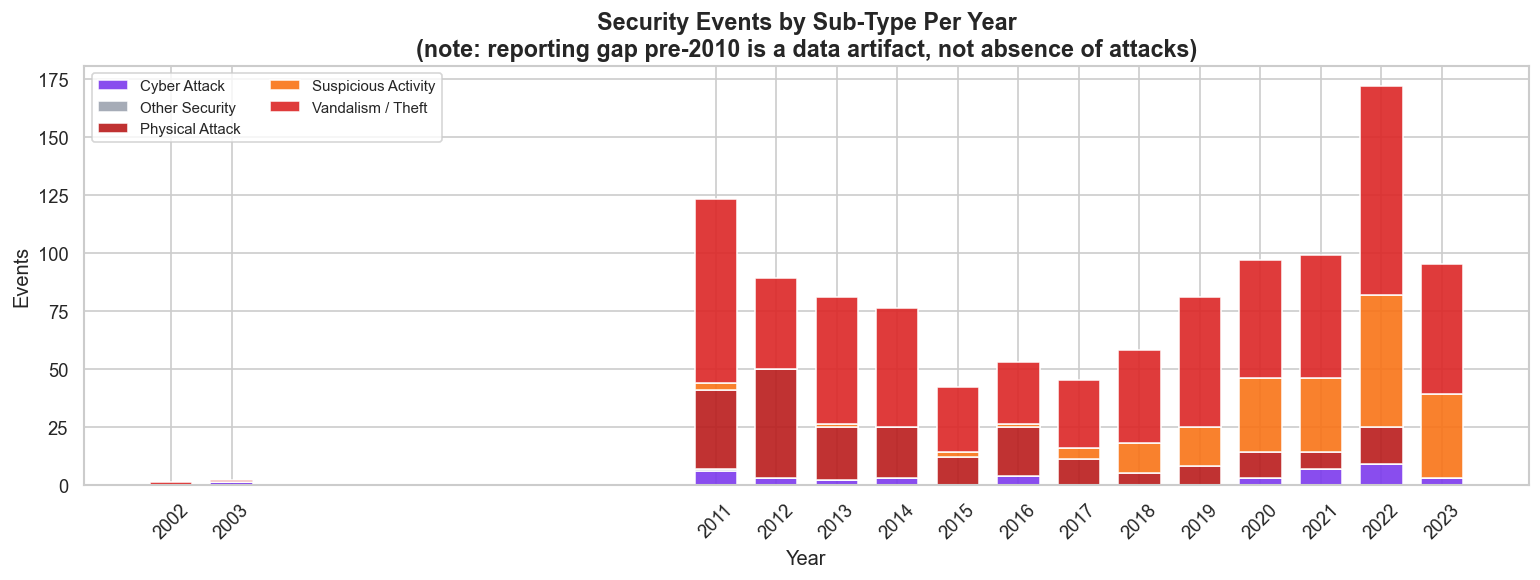

In [17]:
# break down security events into sub-types
def sub_classify(t):
    if pd.isna(t):
        return 'Unknown'
    t = str(t).lower()
    if 'cyber' in t:
        return 'Cyber Attack'
    if any(k in t for k in ['vandal', 'theft']):
        return 'Vandalism / Theft'
    if any(k in t for k in ['physical', 'sabotage', 'actual attack']):
        return 'Physical Attack'
    if 'suspicious' in t:
        return 'Suspicious Activity'
    return 'Other Security'

security['sub_type'] = security['event_type'].apply(sub_classify)

# group by year and sub type for the stacked bar
sub_year = security.groupby(['year_sheet', 'sub_type']).size().unstack(fill_value=0)

sub_colors = {
    'Vandalism / Theft':    '#DC2626',
    'Physical Attack':      '#B91C1C',
    'Suspicious Activity':  '#F97316',
    'Cyber Attack':         '#7C3AED',
    'Other Security':       '#9CA3AF',
}

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(sub_year))
for col in sub_year.columns:
    ax.bar(sub_year.index, sub_year[col], bottom=bottom,
           label=col, color=sub_colors.get(col, '#6B7280'), alpha=0.9, width=0.7)
    bottom += sub_year[col].values

ax.set_xlabel('Year')
ax.set_ylabel('Events')
ax.set_title('Security Events by Sub-Type Per Year\n(note: reporting gap pre-2010 is a data artifact, not absence of attacks)')
ax.legend(ncol=2, fontsize=9)
ax.set_xticks(sub_year.index)
ax.set_xticklabels(sub_year.index, rotation=45)
plt.tight_layout()
plt.show()

## 6. Summary Dashboard and Key Findings

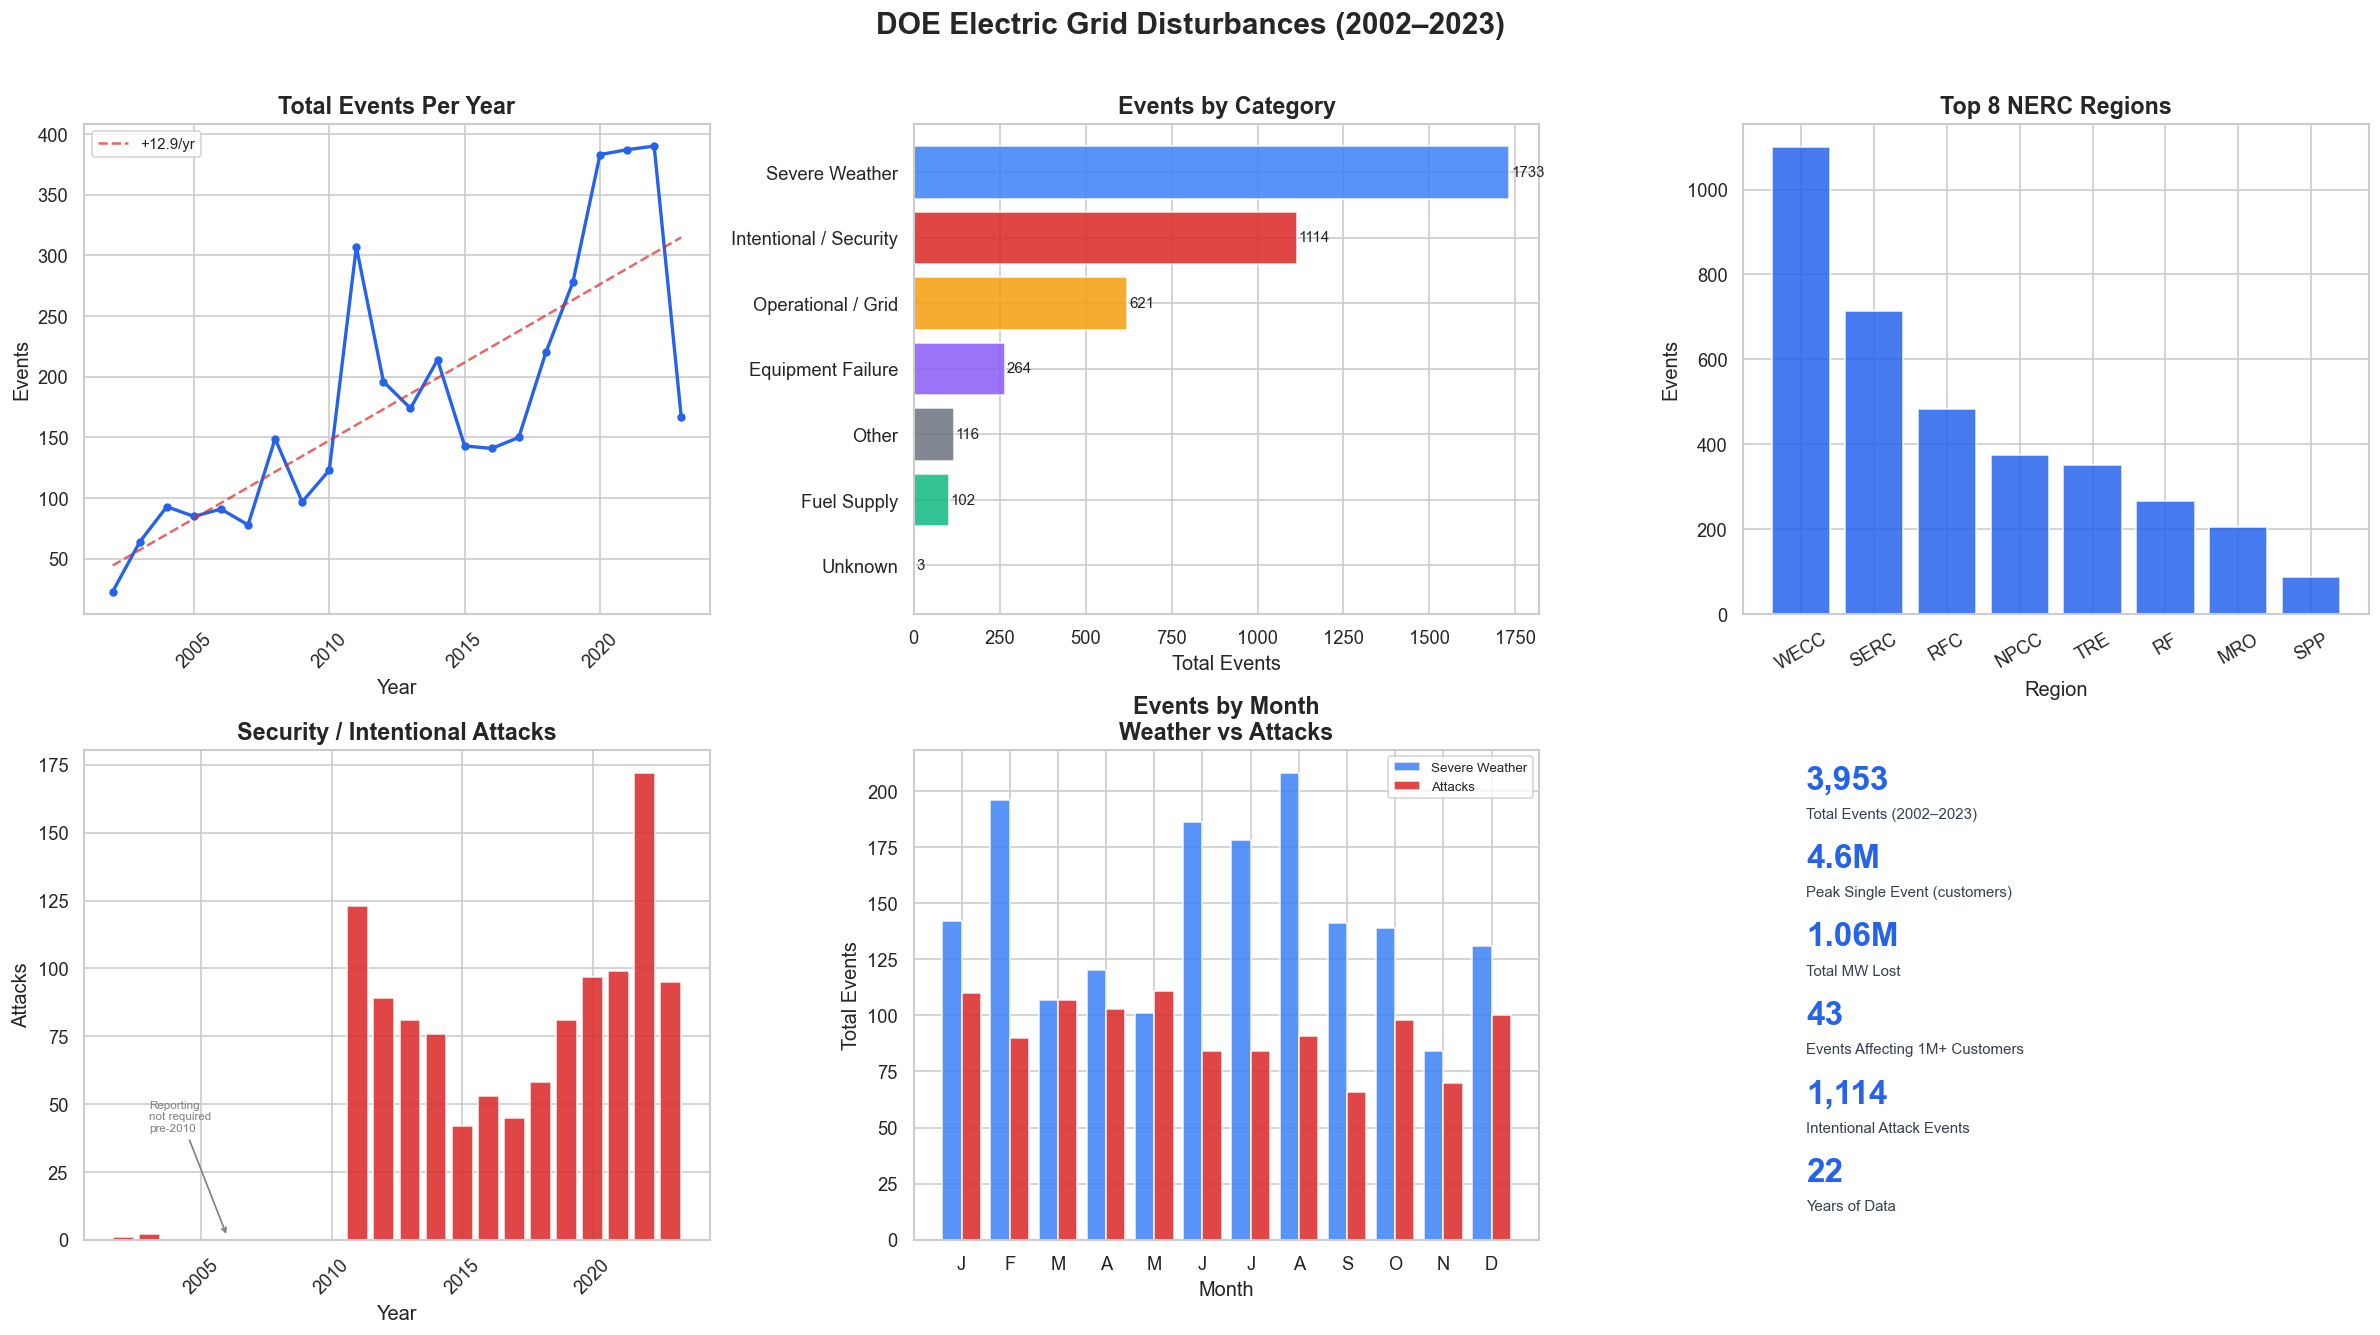

dashboard saved to doe_summary_dashboard.png


In [18]:
# build a 6 panel summary dashboard
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('DOE Electric Grid Disturbances (2002–2023)',
             fontsize=18, fontweight='bold', y=1.01)

# panel 1: events per year with trend line
ax = axes[0, 0]
ax.plot(annual['year_sheet'], annual['events'], color=BLUE, linewidth=2, marker='o', markersize=4)
z = np.polyfit(annual['year_sheet'].astype(int), annual['events'], 1)
p = np.poly1d(z)
ax.plot(annual['year_sheet'], p(annual['year_sheet'].astype(int)), '--', color=RED, alpha=0.7,
        label=f'+{z[0]:.1f}/yr')
ax.set_title('Total Events Per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Events')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)

# panel 2: horizontal bar chart
ax = axes[0, 1]
cat_counts = df['category'].value_counts().sort_values(ascending=True)
bar_colors = [COLORS.get(c, '#6B7280') for c in cat_counts.index]
bars = ax.barh(cat_counts.index, cat_counts.values, color=bar_colors, alpha=0.85)
for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.set_title('Events by Category')
ax.set_xlabel('Total Events')

# panel 3: top 8 regions by event count
ax = axes[0, 2]
rc8 = region_counts.head(8)
ax.bar(rc8.index, rc8.values, color=BLUE, alpha=0.85)
ax.set_title('Top 8 NERC Regions')
ax.set_xlabel('Region')
ax.set_ylabel('Events')
ax.tick_params(axis='x', rotation=30)

# panel 4: intentional attacks per year
ax = axes[1, 0]
ax.bar(sec_year['year_sheet'], sec_year['attacks'], color=RED, alpha=0.85)
ax.annotate('Reporting\nnot required\npre-2010',
            xy=(2006, 1), xytext=(2003, 40),
            fontsize=7, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.0))
ax.set_title('Security / Intentional Attacks')
ax.set_xlabel('Year')
ax.set_ylabel('Attacks')
ax.tick_params(axis='x', rotation=45)

# panel 5: events by month split into weather vs attacks
ax = axes[1, 1]
weather_monthly  = df[df['category'] == 'Severe Weather'].groupby('event_month').size()
security_monthly = df[df['category'] == 'Intentional / Security'].groupby('event_month').size()
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
x = np.arange(1, 13)
ax.bar(x - 0.2, weather_monthly.reindex(x, fill_value=0), width=0.4,
       color='#3B82F6', alpha=0.85, label='Severe Weather')
ax.bar(x + 0.2, security_monthly.reindex(x, fill_value=0), width=0.4,
       color=RED, alpha=0.85, label='Attacks')
ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_title('Events by Month\nWeather vs Attacks')
ax.set_xlabel('Month')
ax.set_ylabel('Total Events')
ax.legend(fontsize=8)

# panel 6: KPI text cards
ax = axes[1, 2]
ax.axis('off')
total_mw  = df['demand_loss_mw'].sum()
max_1m    = (df['customers_affected'] >= 1_000_000).sum()
peak_evt  = df['customers_affected'].max()

kpis = [
    (f'{len(df):,}',             'Total Events (2002–2023)'),
    (f'{peak_evt/1e6:.1f}M',     'Peak Single Event (customers)'),
    (f'{total_mw/1e6:.2f}M',     'Total MW Lost'),
    (f'{max_1m}',                'Events Affecting 1M+ Customers'),
    (f'{len(security):,}',       'Intentional Attack Events'),
    (f'{df["year_sheet"].nunique()}', 'Years of Data'),
]

for i, (val, label) in enumerate(kpis):
    y_pos = 0.92 - i * 0.16
    ax.text(0.1, y_pos, val, transform=ax.transAxes,
            fontsize=20, fontweight='bold', color=BLUE)
    ax.text(0.1, y_pos - 0.06, label, transform=ax.transAxes,
            fontsize=9, color='#374151')

plt.tight_layout()
plt.savefig('doe_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('dashboard saved to doe_summary_dashboard.png')